In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4966
Epoca [10/100] | Loss: 0.1906
Epoca [20/100] | Loss: 0.0498
Epoca [30/100] | Loss: 0.0192
Epoca [40/100] | Loss: 0.0092
Epoca [50/100] | Loss: 0.0056
Epoca [60/100] | Loss: 0.0041
Epoca [70/100] | Loss: 0.0033
Epoca [80/100] | Loss: 0.0029
Epoca [90/100] | Loss: 0.0027
Epoca [100/100] | Loss: 0.0025

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0041
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

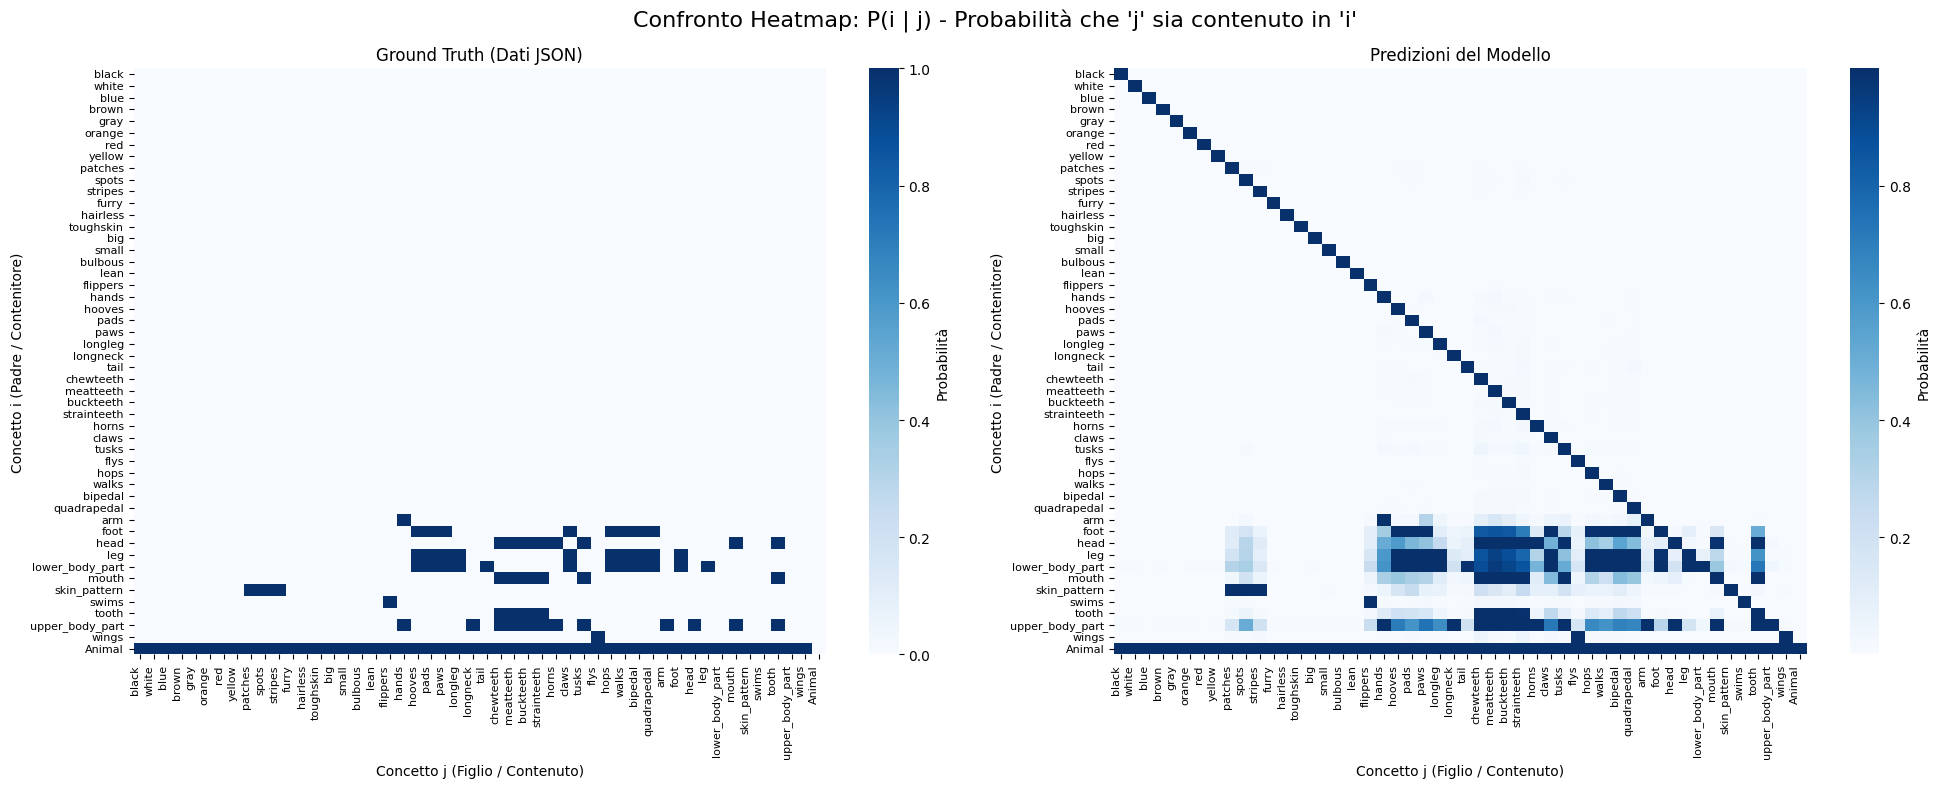

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

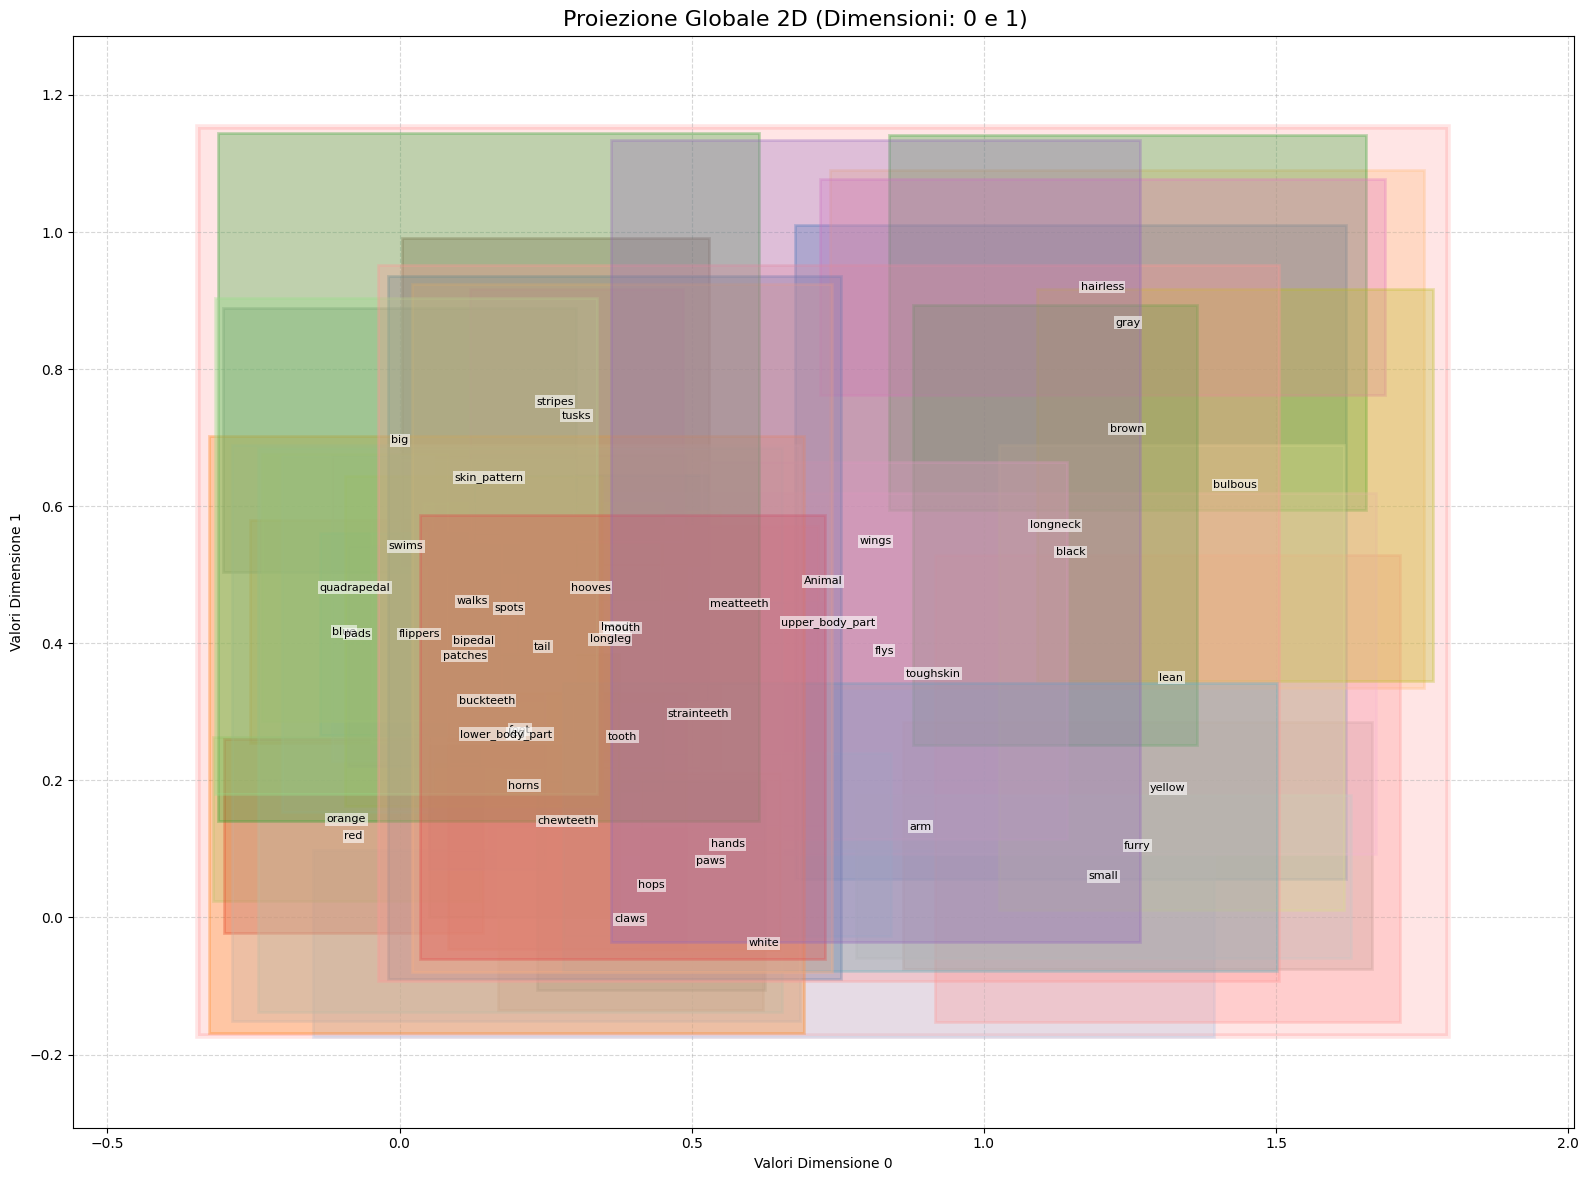

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

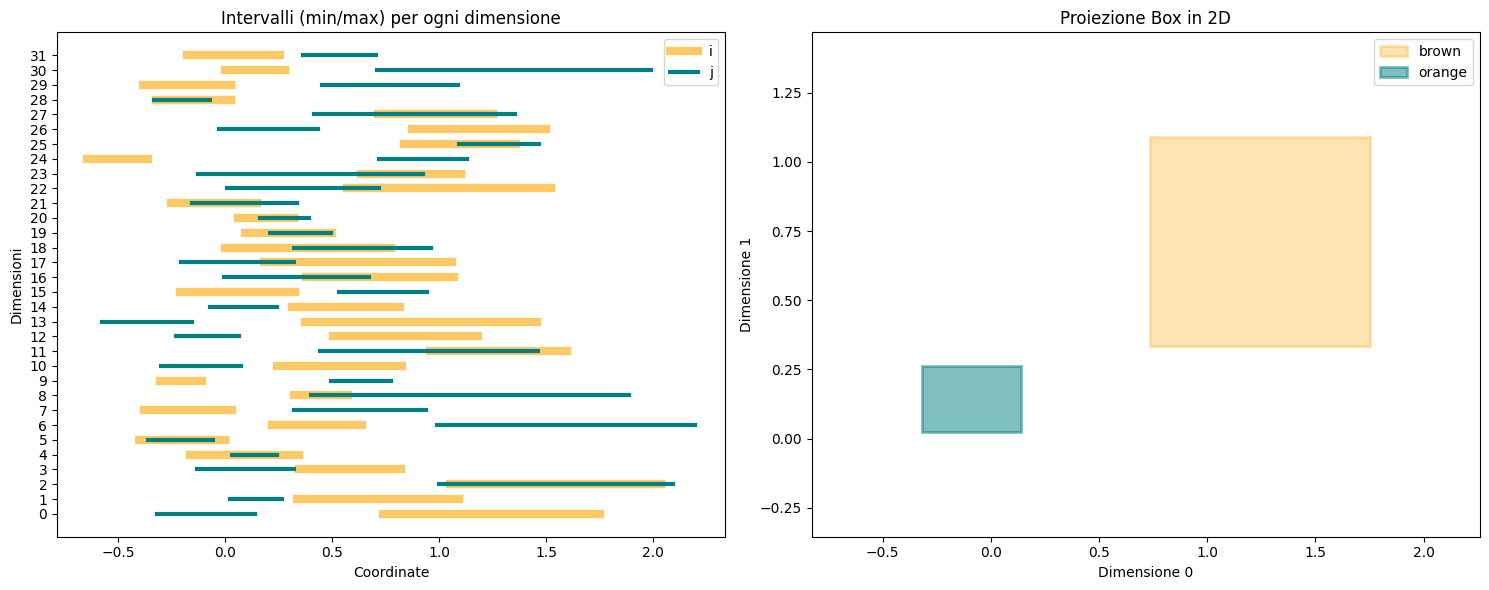

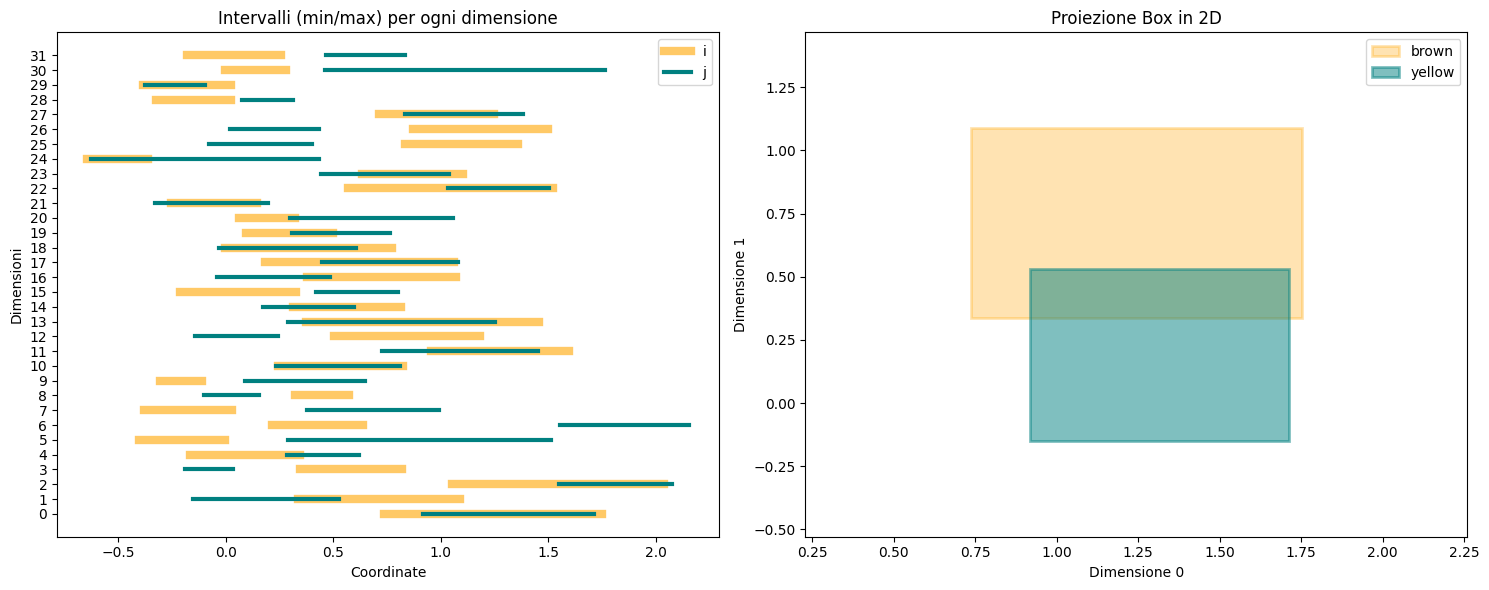

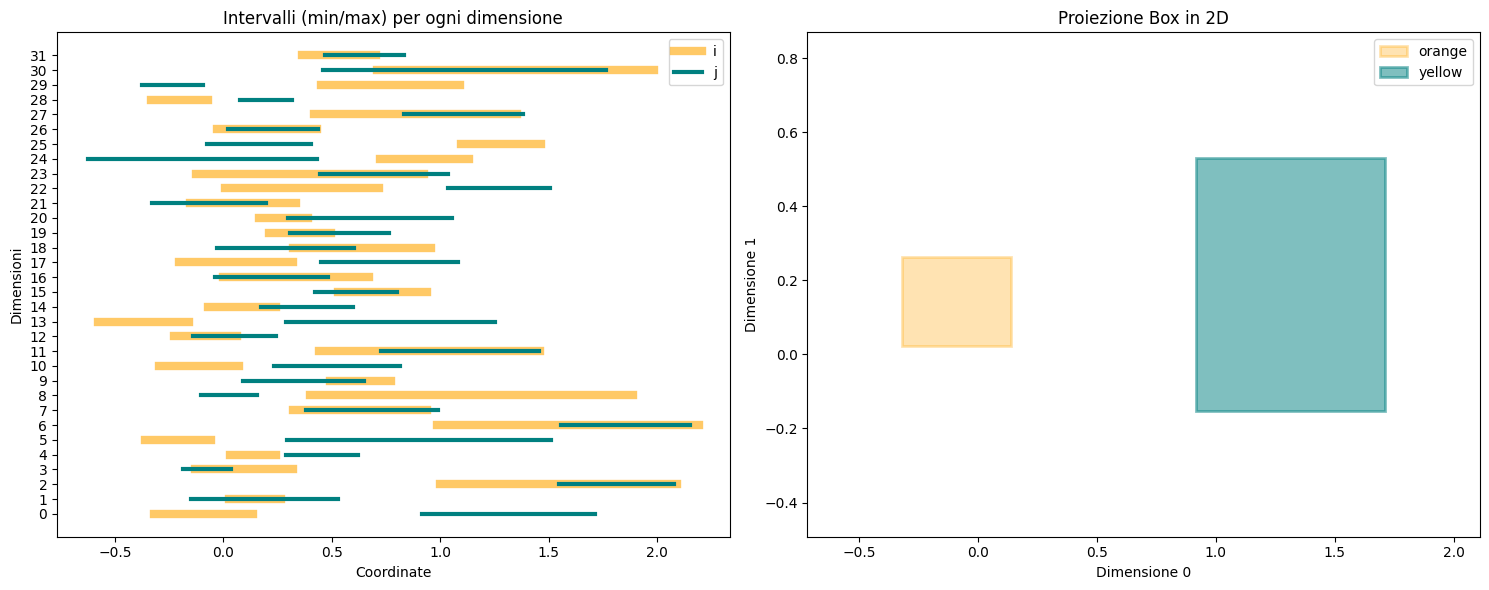

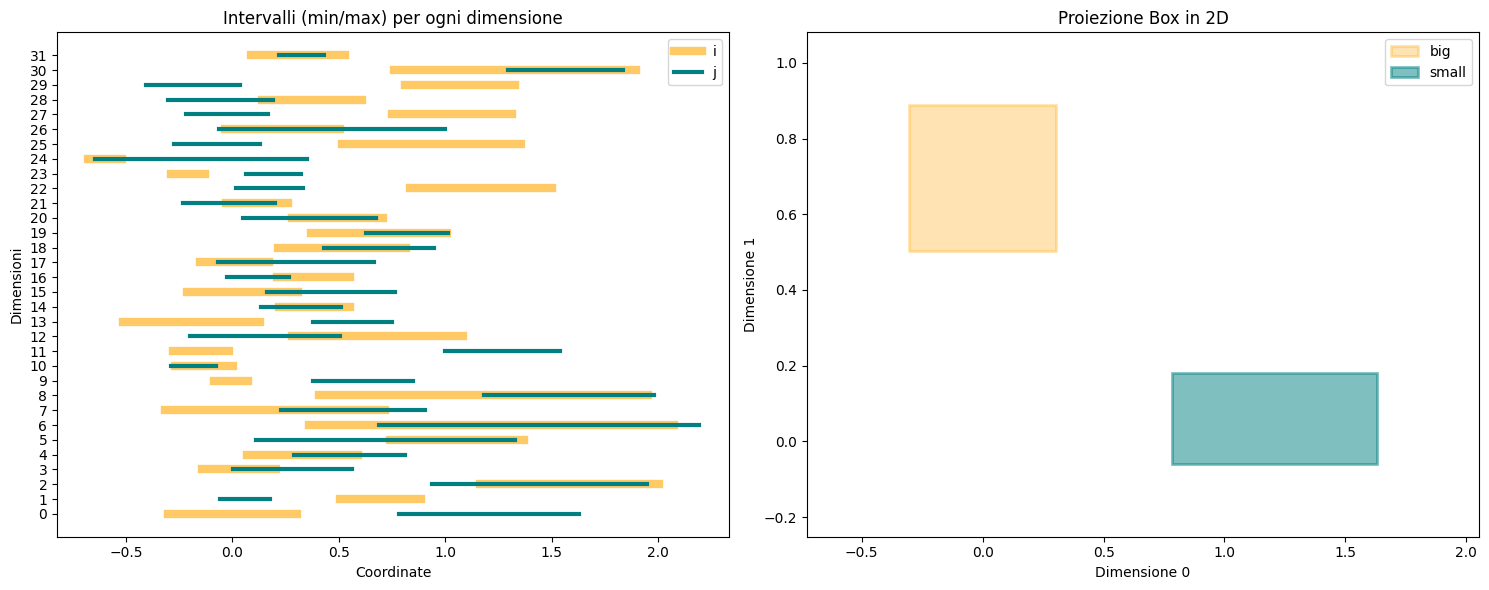

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.7953, 1.1532, 2.1069, 1.0404, 0.9217, 1.5463, 2.2383, 1.2043, 2.0404,
         0.9709, 1.0068, 1.6180, 1.2022, 1.4769, 1.0353, 0.9678, 1.2206, 1.1806,
         0.9853, 1.1193, 1.0784, 0.9028, 1.6048, 1.1865, 1.2201, 1.4738, 1.6374,
         1.5106, 1.2008, 1.4066, 1.9917, 0.9480]])
Coordinate z (min) per 'wings': tensor([[ 0.3617, -0.0365, -0.2227,  0.0242, -0.2173,  0.4251,  0.8991,  0.1845,
          0.3178,  0.2567, -0.0985,  0.4744,  0.2319,  0.2970, -0.2038, -0.1060,
          0.1632, -0.1772,  0.0400, -0.0415,  0.3029,  0.2188, -0.0376, -0.2817,
         -0.6385, -0.3341,  0.5131,  0.7649,  0.3580, -0.4547, -0.3537, -0.1179]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.7953, 1.1532, 2.1069, 1.0404, 0.9217, 1.5463, 2.2383, 1.2043, 2.0404,
         0.9709, 1.0068, 1.6180, 1.2022, 1.4769, 1.0353, 0.9678, 1.2206, 1.1806,
         0.9853, 1.1193, 1.0784, 0.9028, 1.6048, 1.1865, 1.2201, 1.4738, 1.6374,
         1.5106, 1.2008, 1.4066, 1.9917, 0.9480]])
Coordinate z (min) per 'wings': tensor([[ 0.3617, -0.0365, -0.2227,  0.0242, -0.2173,  0.4251,  0.8991,  0.1845,
          0.3178,  0.2567, -0.0985,  0.4744,  0.2319,  0.2970, -0.2038, -0.1060,
          0.1632, -0.1772,  0.0400, -0.0415,  0.3029,  0.2188, -0.0376, -0.2817,
         -0.6385, -0.3341,  0.5131,  0.7649,  0.3580, -0.4547, -0.3537, -0.1179]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier, plot_test_results

### CBM with boxes

#### Train

In [21]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.081, Acc=98.8% | VAL: Loss=0.003, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

In [ ]:
from src.CHM.train import plot_history
plot_history(b_history)

#### Test

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors)

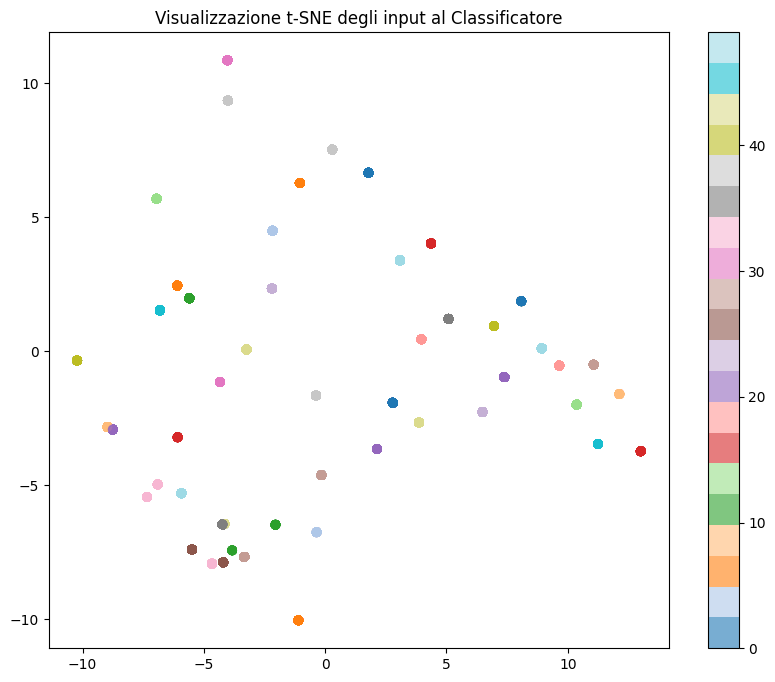

In [22]:
from src.CHM.interpretation import visualizza_separabilita, shuffle_test

visualizza_separabilita(
    model=b_model,
    test_dataloader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    projection_method='pca'
)

In [ ]:
shuffle_test(b_model, test_dataloader, class_concept_matrix, box_tensors)

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

In [ ]:
from src.CHM.train import plot_history
plot_history(cp_history)

#### Test

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [ ]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
from src.CHM.train import plot_history
plot_history(c_history)

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

In [ ]:
from src.CHM.interpretation import visualizza_separabilita, shuffle_test

visualizza_separabilita(
    model=c_model,
    test_dataloader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    info=info,
    bipolar=bipolar
)

In [ ]:
shuffle_test(c_model, test_dataloader, class_concept_matrix, box_tensors, info=info, bipolar=bipolar)

## NEXT

1. controllare 100% accuracy sospetto
2. valutare istanza per istanza interpretazione
3. training x -> c_pred

## Concept Predictor

In [ ]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)